In [6]:
import pandas as pd

df = pd.read_csv("traffic.csv")

print(df.head())

              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041


In [7]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB
None
DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64


In [8]:
df = df.dropna()

In [20]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df['hour'] = df['DateTime'].dt.hour
df['day'] = df['DateTime'].dt.day
df['month'] = df['DateTime'].dt.month
df['year'] = df['DateTime'].dt.year

In [18]:
df.head()

,DateTime,Junction,Vehicles,ID,hour,day,month
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [24]:
predictions = model.predict(X_test)

print(predictions[:5])

[ 9.72 52.69  8.82 10.6  18.74]


In [25]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 2.8773243973399834


In [26]:
print(df.columns)

Index(['DateTime', 'Junction', 'Vehicles', 'ID', 'hour', 'day', 'month',
       'year'],
      dtype='str')


# EDA(Exploratory Data Analysis)

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

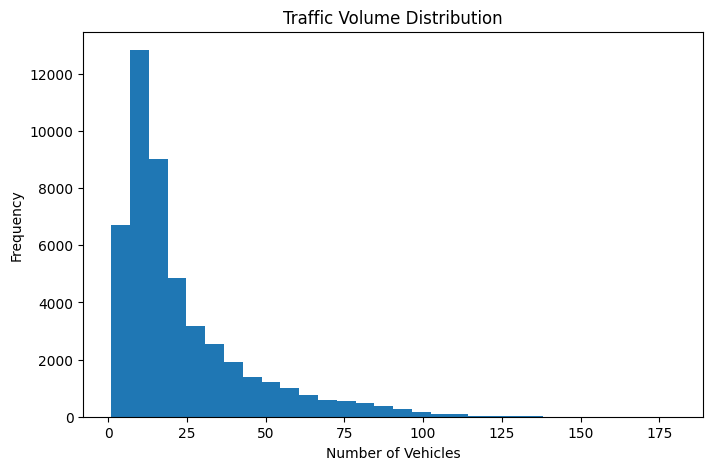

In [33]:
# Traffic Volume Distribution
plt.figure(figsize=(8,5))

plt.hist(df['Vehicles'], bins=30)

plt.title("Traffic Volume Distribution")
plt.xlabel("Number of Vehicles")
plt.ylabel("Frequency")

plt.show()

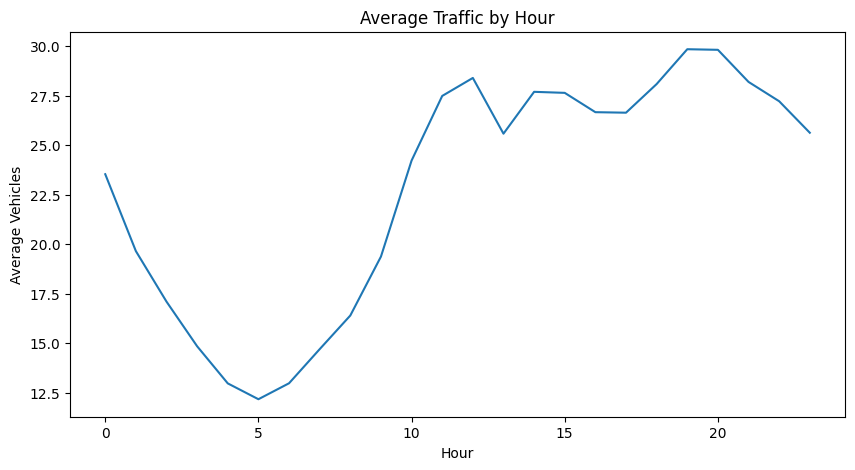

In [34]:
# Traffic by Hour
traffic_by_hour = df.groupby('hour')['Vehicles'].mean()

plt.figure(figsize=(10,5))

traffic_by_hour.plot()

plt.title("Average Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Vehicles")

plt.show()

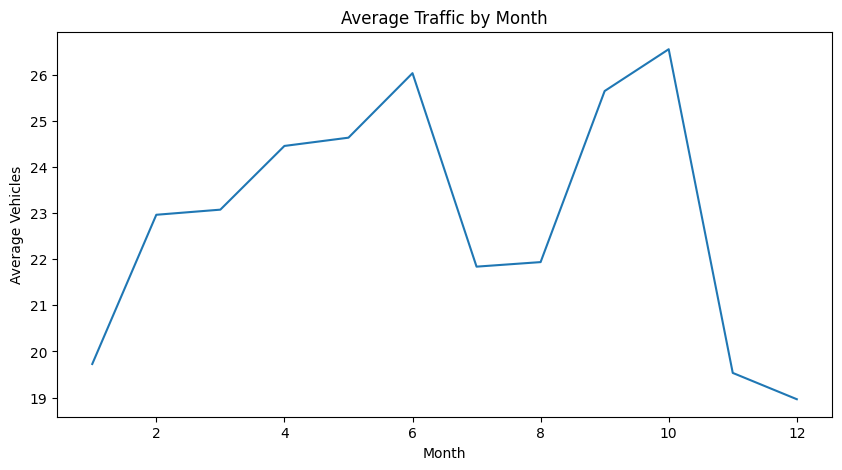

In [35]:
# Traffic by Month
traffic_by_month = df.groupby('month')['Vehicles'].mean()

plt.figure(figsize=(10,5))

traffic_by_month.plot()

plt.title("Average Traffic by Month")
plt.xlabel("Month")
plt.ylabel("Average Vehicles")

plt.show()

In [ ]:
# Traffic by Junction

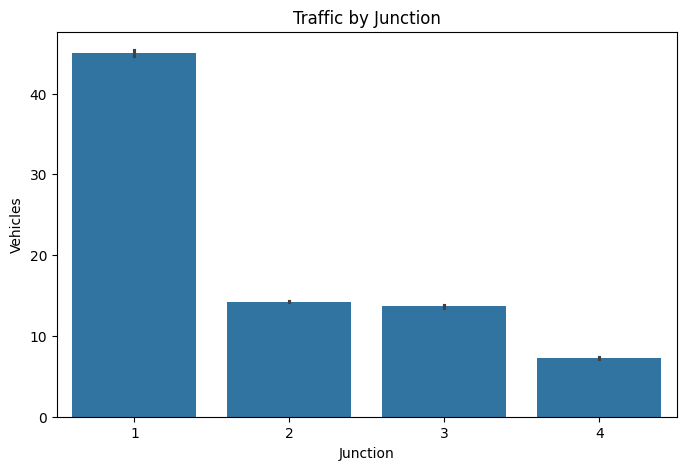

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(x='Junction', y='Vehicles', data=df)

plt.title("Traffic by Junction")

plt.show()

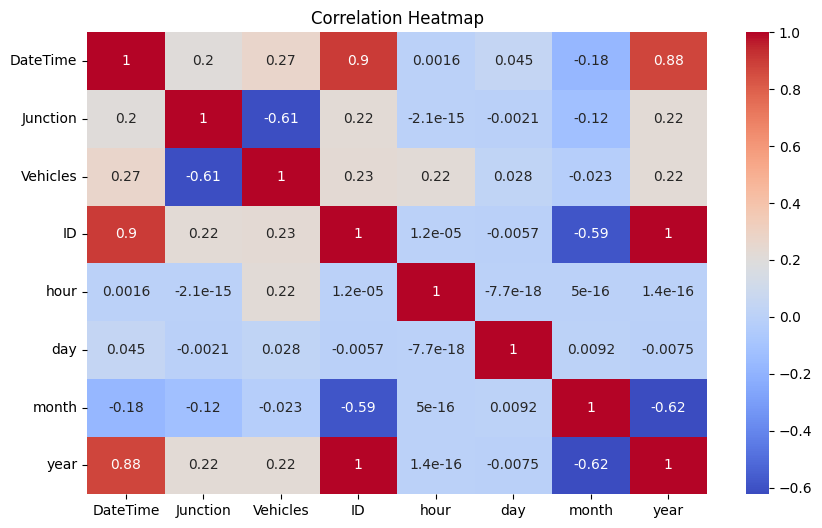

In [37]:
# Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

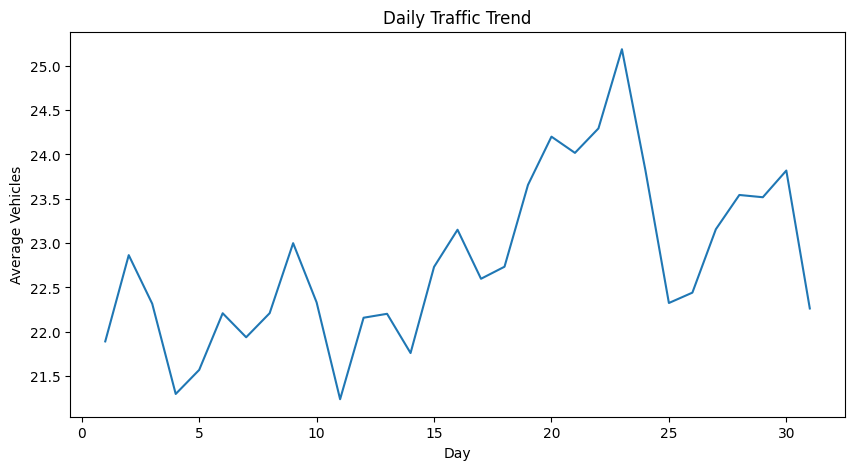

In [38]:
# Daily Traffic Trend
daily_traffic = df.groupby('day')['Vehicles'].mean()

plt.figure(figsize=(10,5))

daily_traffic.plot()

plt.title("Daily Traffic Trend")
plt.xlabel("Day")
plt.ylabel("Average Vehicles")

plt.show()

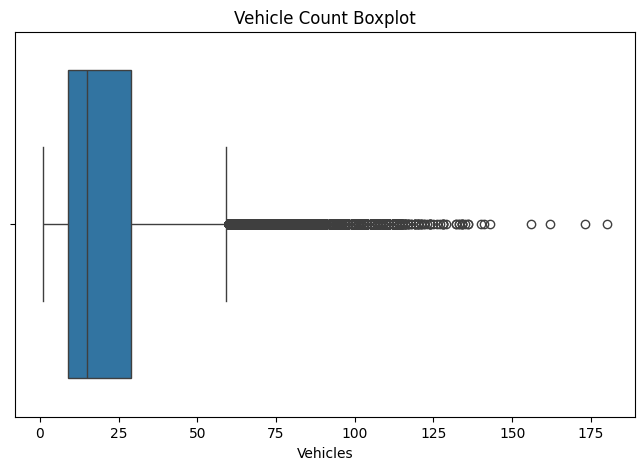

In [39]:
# Boxplot for Vehicle Distribution
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Vehicles'])

plt.title("Vehicle Count Boxplot")

plt.show()

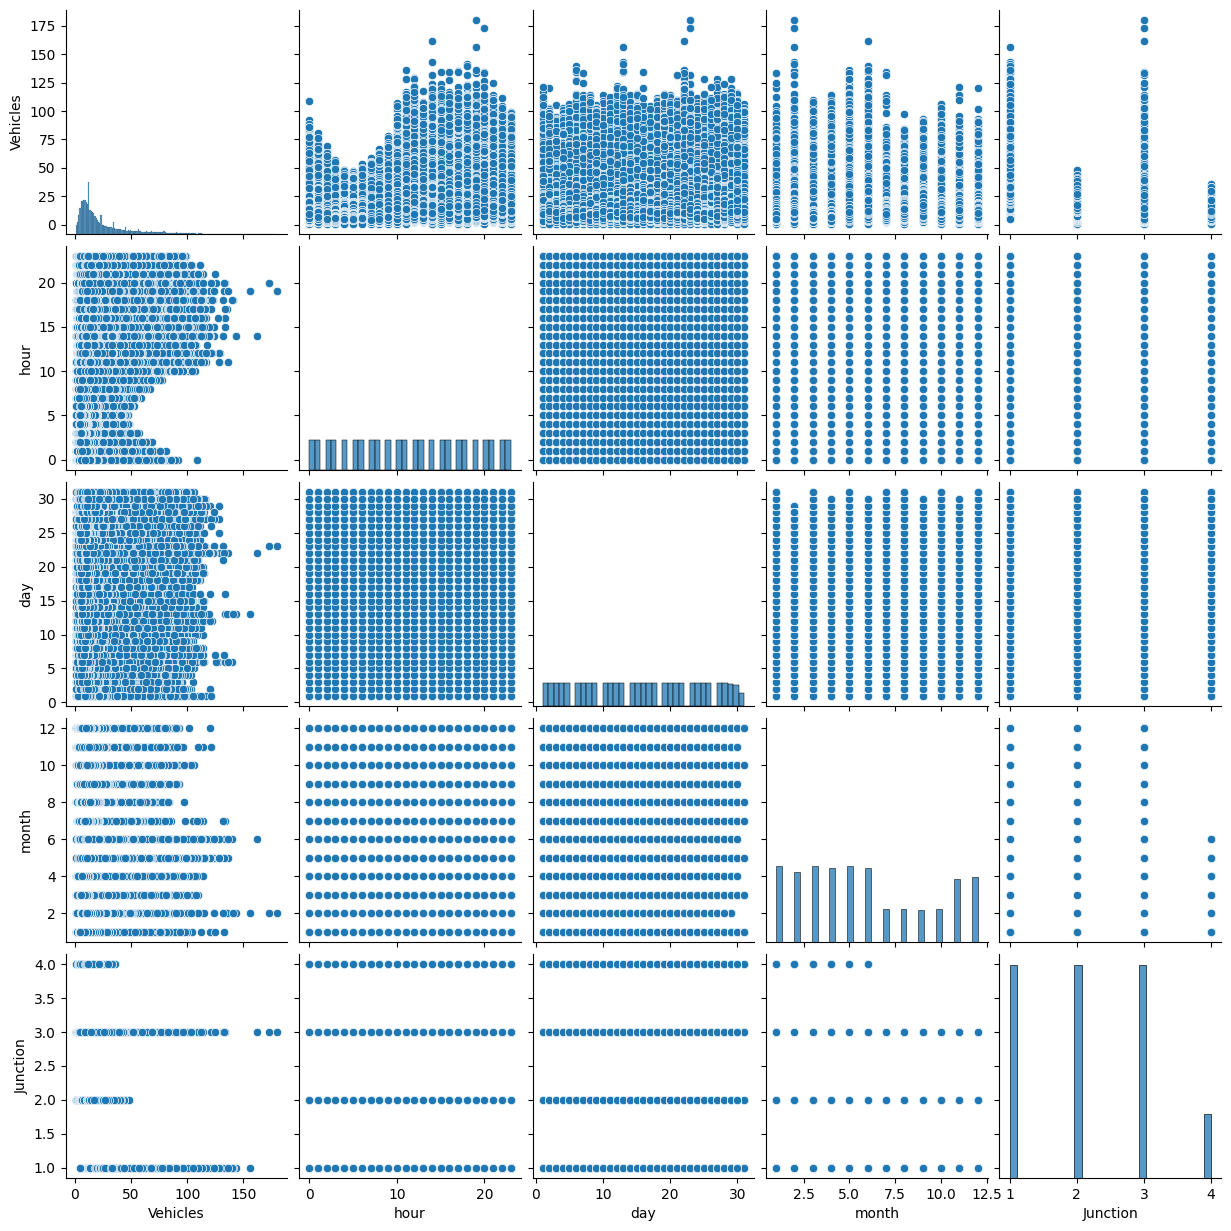

In [40]:
# pairplot
sns.pairplot(df[['Vehicles', 'hour', 'day', 'month', 'Junction']])

plt.show()

# MACHINE LEARNING MODEL

In [52]:
X = df[['hour', 'day', 'month', 'year', 'Junction']]
y = df['Vehicles']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [54]:
trained_features = model.feature_names_in_

X_test = X_test[trained_features]

predictions = model.predict(X_test)
print(predictions[:10])

[ 9.8  58.25  9.19 10.63 18.47 10.63 13.27 15.99 12.69 21.41]


In [55]:
# Evaluate Module
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 2.86839463840399
MSE: 18.483989079384873
R2 Score: 0.9546457201431429


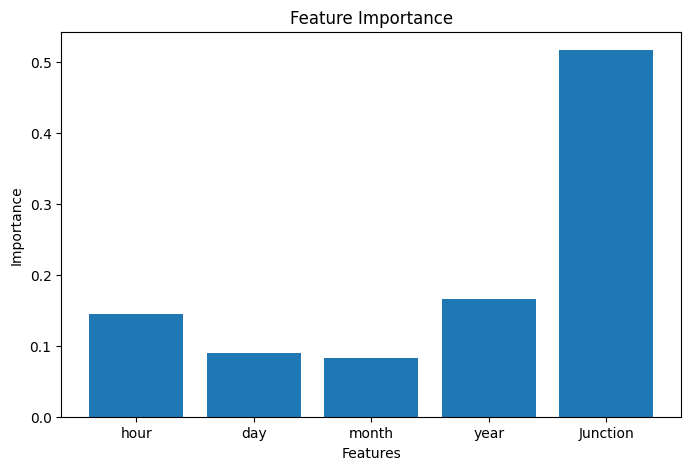

In [59]:
# Feature importance Graph
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.title("Feature Importance")

plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

# save Model

In [60]:
import joblib

joblib.dump(model, "traffic_model.pkl")

['traffic_model.pkl']

In [64]:
# Test Real Prediction
sample = pd.DataFrame({
    'hour': [18],
    'day': [15],
    'month': [5],
    'year': [2017],
    'Junction': [1]
})

predictions = model.predict(sample)

print("Predicted Traffic Volume:", predictions[0])

Predicted Traffic Volume: 104.28
